# SSRO Readout — ML State Discrimination

Trains and evaluates classifiers on integrated IQ data from single-shot readout (SSRO) experiments,
with an architecture grid search and a forward-looking plan for raw-trace CNN discrimination.

**Contents**
1. Load data
2. IQ scatter plot
3. Train/test split + scaling
4. Train LDA and MLP baselines
5. Evaluate — assignment fidelity
6. Decision boundaries
7. Confusion matrices
8. LDA projection — 1D histogram
9. MLP probability scores
10. Architecture grid search
11. Grid search results
12. Forward plan — raw-trace 1D CNN
13. Summary

**Data layout:** `SSRO.h5` → `results` array of shape `(2, 2001, 2)`:  
axis 0 = prepared state (`off`=|0⟩, `on`=|1⟩), axis 1 = shots, axis 2 = [I, Q]

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Load data

In [4]:
H5_PATH = './ssro_h5/SSRO_0.h5'  # adjust path if needed

with h5py.File(H5_PATH, 'r') as f:
    results = f['results'][:]          # (2, 2001, 2)
    state_labels = f['loops/state'][:] # [b'off', b'on']

# Drop first shot (potential artefact — first entry sits slightly off-mean)
X0 = results[0, 1:, :]  # |0> IQ, shape (2000, 2)
X1 = results[1, 1:, :]  # |1> IQ, shape (2000, 2)
X  = np.vstack([X0, X1])
y  = np.array([0]*len(X0) + [1]*len(X1))

print(f"Loaded {len(X0)} |0> shots and {len(X1)} |1> shots")
print(f"IQ range — I: [{X[:,0].min():.2f}, {X[:,0].max():.2f}], "
      f"Q: [{X[:,1].min():.2f}, {X[:,1].max():.2f}]")

Loaded 2000 |0> shots and 2000 |1> shots
IQ range — I: [-3.58, 1.07], Q: [2.80, 9.23]


## 2. IQ scatter plot — raw blobs

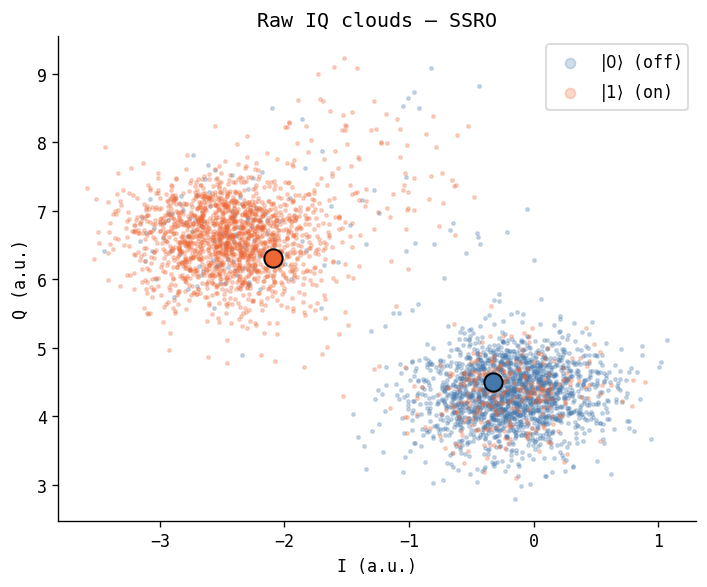

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(X0[:, 0], X0[:, 1], s=4, alpha=0.25, color='#4477AA', label=r'$|0\rangle$ (off)', rasterized=True)
ax.scatter(X1[:, 0], X1[:, 1], s=4, alpha=0.25, color='#EE6633', label=r'$|1\rangle$ (on)',  rasterized=True)

# Mark centroids
ax.scatter(*X0.mean(axis=0), s=120, color='#4477AA', edgecolors='k', linewidths=1.2, zorder=5)
ax.scatter(*X1.mean(axis=0), s=120, color='#EE6633', edgecolors='k', linewidths=1.2, zorder=5)

ax.set_xlabel('I (a.u.)')
ax.set_ylabel('Q (a.u.)')
ax.set_title('Raw IQ clouds — SSRO')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('iq_scatter.pdf', bbox_inches='tight')
plt.show()

## 3. Train/test split + scaling

In [6]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# StandardScaler: zero-mean, unit-variance — required for MLP, harmless for LDA
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)} shots | Test: {len(X_test)} shots")

Train: 3200 shots | Test: 800 shots


## 4. Train classifiers

In [7]:
# LDA — fits a linear boundary; equivalent to optimal threshold on the projected axis
# when blobs are Gaussian with equal covariance
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# MLP — small 2-layer net; input (I,Q) -> 32 -> 16 -> sigmoid output
# Hidden layer sizes are intentionally small: fits in ~1k LUTs after hls4ml quantization
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    max_iter=2000,
    random_state=RANDOM_STATE
)
mlp.fit(X_train_s, y_train)

print(f"MLP converged in {mlp.n_iter_} iterations")

MLP converged in 92 iterations


## 5. Evaluate — assignment fidelity

In [8]:
def assignment_fidelity(model, X, y):
    """
    Returns (fidelity, acc0, acc1).
    Assignment fidelity F = (P(correct|0) + P(correct|1)) / 2
                          = 1 - (e01 + e10)/2
    where e01 = P(predict 1 | prepared 0), i.e. the mis-assignment rates.
    """
    pred = model.predict(X)
    mask0, mask1 = y == 0, y == 1
    acc0 = (pred[mask0] == 0).mean()
    acc1 = (pred[mask1] == 1).mean()
    return (acc0 + acc1) / 2, acc0, acc1

lda_fid, lda_acc0, lda_acc1 = assignment_fidelity(lda, X_test, y_test)
mlp_fid, mlp_acc0, mlp_acc1 = assignment_fidelity(mlp, X_test_s, y_test)

print("=" * 45)
print(f"{'Model':<8}  {'Fidelity':>9}  {'|0> acc':>8}  {'|1> acc':>8}")
print("-" * 45)
print(f"{'LDA':<8}  {lda_fid:>9.4f}  {lda_acc0:>8.4f}  {lda_acc1:>8.4f}")
print(f"{'MLP':<8}  {mlp_fid:>9.4f}  {mlp_acc0:>8.4f}  {mlp_acc1:>8.4f}")
print("=" * 45)
print()
print("Note: |0> accuracy > |1> accuracy is typical — T1 decay during")
print("readout causes some |1> shots to relax and land in the |0> blob.")

Model      Fidelity   |0> acc   |1> acc
---------------------------------------------
LDA          0.9062    0.9400    0.8725
MLP          0.9062    0.9400    0.8725

Note: |0> accuracy > |1> accuracy is typical — T1 decay during
readout causes some |1> shots to relax and land in the |0> blob.


## 6. Decision boundaries

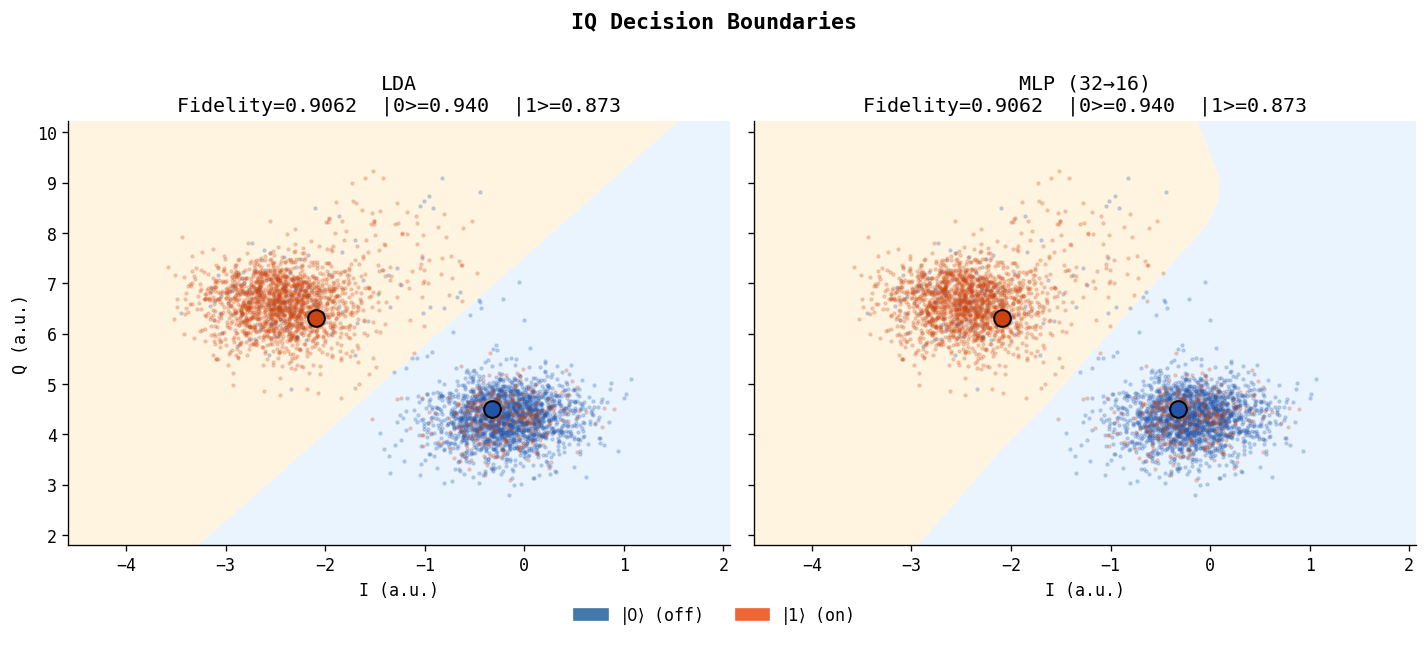

In [9]:
# Build a 2D grid over IQ space
pad = 1.0
i_min, i_max = X[:,0].min() - pad, X[:,0].max() + pad
q_min, q_max = X[:,1].min() - pad, X[:,1].max() + pad
ii, qq = np.meshgrid(np.linspace(i_min, i_max, 400),
                     np.linspace(q_min, q_max, 400))
grid   = np.c_[ii.ravel(), qq.ravel()]
grid_s = scaler.transform(grid)

Z_lda = lda.predict(grid).reshape(ii.shape)
Z_mlp = mlp.predict(grid_s).reshape(ii.shape)

cmap_bg = ListedColormap(['#DDEEFF', '#FFEECC'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, Z, title, fid, acc0, acc1 in [
    (axes[0], Z_lda, 'LDA', lda_fid, lda_acc0, lda_acc1),
    (axes[1], Z_mlp, 'MLP (32→16)', mlp_fid, mlp_acc0, mlp_acc1),
]:
    ax.pcolormesh(ii, qq, Z, cmap=cmap_bg, alpha=0.6, shading='auto')
    ax.scatter(X0[:, 0], X0[:, 1], s=3, alpha=0.2, color='#2255AA', rasterized=True)
    ax.scatter(X1[:, 0], X1[:, 1], s=3, alpha=0.2, color='#CC4411', rasterized=True)
    ax.scatter(*X0.mean(axis=0), s=100, color='#2255AA', edgecolors='k', lw=1.2, zorder=5)
    ax.scatter(*X1.mean(axis=0), s=100, color='#CC4411', edgecolors='k', lw=1.2, zorder=5)
    ax.set_title(f'{title}\nFidelity={fid:.4f}  |0>={acc0:.3f}  |1>={acc1:.3f}')
    ax.set_xlabel('I (a.u.)')
    ax.set_xlim(i_min, i_max)
    ax.set_ylim(q_min, q_max)

axes[0].set_ylabel('Q (a.u.)')

p0 = mpatches.Patch(color='#4477AA', label=r'$|0\rangle$ (off)')
p1 = mpatches.Patch(color='#EE6633', label=r'$|1\rangle$ (on)')
fig.legend(handles=[p0, p1], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('IQ Decision Boundaries', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('decision_boundaries.pdf', bbox_inches='tight')
plt.show()

## 7. Confusion matrices

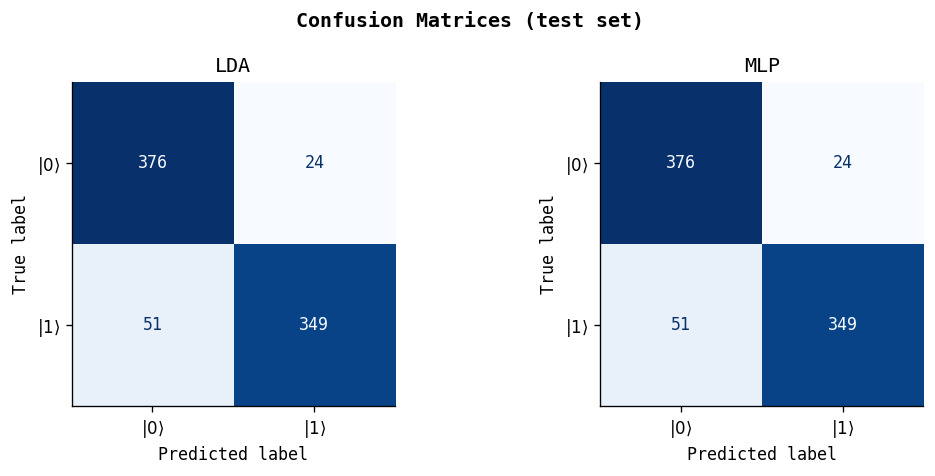

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, model, X_in, title in [
    (axes[0], lda, X_test,   'LDA'),
    (axes[1], mlp, X_test_s, 'MLP'),
]:
    cm = confusion_matrix(y_test, model.predict(X_in))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[r'$|0\rangle$', r'$|1\rangle$']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.suptitle('Confusion Matrices (test set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.pdf', bbox_inches='tight')
plt.show()

## 8. LDA projection — 1D histogram

Projects all IQ shots onto the LDA discriminant axis. This is the 1D scalar that a simple
threshold classifier uses — and what a QICK tProc threshold register would implement directly.

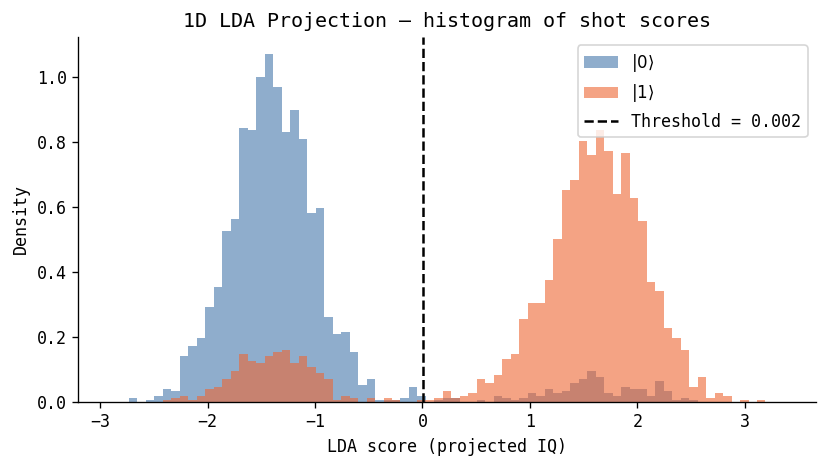

Projected SNR (Mahalanobis-like): 2.464
LDA threshold on projected axis:  0.0016


In [11]:
# Project onto LDA discriminant axis
proj0 = lda.transform(X0).ravel()
proj1 = lda.transform(X1).ravel()

fig, ax = plt.subplots(figsize=(7, 4))

bins = np.linspace(
    min(proj0.min(), proj1.min()) - 0.2,
    max(proj0.max(), proj1.max()) + 0.2,
    80
)

ax.hist(proj0, bins=bins, alpha=0.6, color='#4477AA', density=True, label=r'$|0\rangle$')
ax.hist(proj1, bins=bins, alpha=0.6, color='#EE6633', density=True, label=r'$|1\rangle$')

# Threshold = midpoint of projected class means (optimal for equal-covariance Gaussians)
threshold = (proj0.mean() + proj1.mean()) / 2
ax.axvline(threshold, color='k', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold:.3f}')

ax.set_xlabel('LDA score (projected IQ)')
ax.set_ylabel('Density')
ax.set_title('1D LDA Projection — histogram of shot scores')
ax.legend()
plt.tight_layout()
plt.savefig('lda_histogram.pdf', bbox_inches='tight')
plt.show()

# SNR estimate: separation / average width
snr = abs(proj0.mean() - proj1.mean()) / ((proj0.std() + proj1.std()) / 2)
print(f"Projected SNR (Mahalanobis-like): {snr:.3f}")
print(f"LDA threshold on projected axis:  {threshold:.4f}")

## 9. MLP probability scores — soft readout

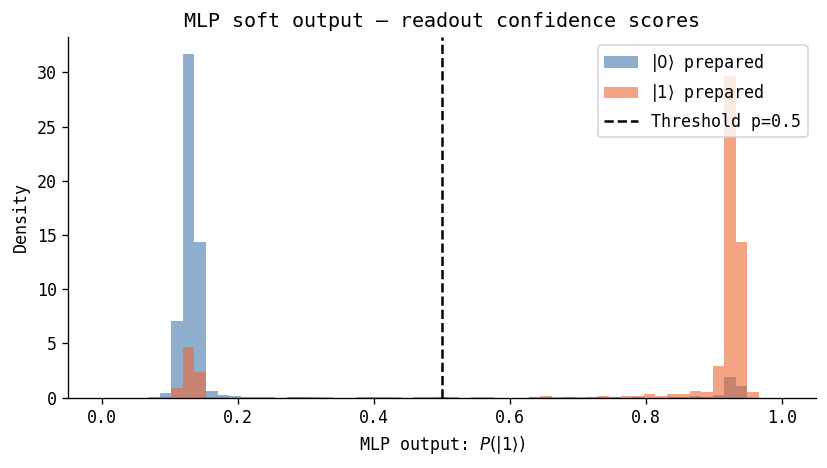

In [12]:
# MLP outputs a probability P(|1>) for each shot
proba0 = mlp.predict_proba(scaler.transform(X0))[:, 1]  # P(|1> | prepared |0>)
proba1 = mlp.predict_proba(scaler.transform(X1))[:, 1]  # P(|1> | prepared |1>)

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 60)
ax.hist(proba0, bins=bins, alpha=0.6, color='#4477AA', density=True, label=r'$|0\rangle$ prepared')
ax.hist(proba1, bins=bins, alpha=0.6, color='#EE6633', density=True, label=r'$|1\rangle$ prepared')
ax.axvline(0.5, color='k', linestyle='--', linewidth=1.5, label='Threshold p=0.5')
ax.set_xlabel(r'MLP output: $P(|1\rangle)$')
ax.set_ylabel('Density')
ax.set_title('MLP soft output — readout confidence scores')
ax.legend()
plt.tight_layout()
plt.savefig('mlp_probabilities.pdf', bbox_inches='tight')
plt.show()

## 10. Architecture grid search

Sweeps MLP depth (1–3 hidden layers) and width (4–64 neurons) using 5-fold stratified
cross-validation. The goal is to determine whether any nonlinear architecture can improve
on the LDA baseline given integrated (I, Q) inputs only.

The key question being tested: are the IQ blobs linearly separable, or is there nonlinear
structure (e.g. multi-modal |1⟩ blob from T1 transitions, leakage to |2⟩) that an MLP
could exploit?

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# LDA cross-validated baseline
lda_cv_scores = []
for tr, te in cv.split(X, y):
    _lda = LinearDiscriminantAnalysis()
    _lda.fit(X[tr], y[tr])
    pred = _lda.predict(X[te])
    m0, m1 = y[te] == 0, y[te] == 1
    lda_cv_scores.append(((pred[m0]==0).mean() + (pred[m1]==1).mean()) / 2)

lda_cv_mean = np.mean(lda_cv_scores)
lda_cv_std  = np.std(lda_cv_scores)
print(f"LDA (5-fold CV): {lda_cv_mean:.4f} ± {lda_cv_std:.4f}")

# Architecture grid
widths = [4, 8, 16, 32, 64]
architectures = (
    [(w,)          for w in widths] +   # 1 hidden layer, constant width
    [(w, w)        for w in widths] +   # 2 hidden layers, constant width
    [(w, w//2)     for w in widths] +   # 2 hidden layers, tapering
    [(w, w, w//2)  for w in widths]     # 3 hidden layers, tapering
)

grid_results = []
print(f"\n{'Architecture':<22} {'Fidelity':>9}  {'±std':>7}  {'Params':>7}  {'vs LDA':>8}")
print("-" * 60)

for arch in architectures:
    fold_fids = []
    for tr, te in cv.split(X, y):
        _scaler = StandardScaler()
        Xtr_s = _scaler.fit_transform(X[tr])
        Xte_s = _scaler.transform(X[te])
        _mlp = MLPClassifier(hidden_layer_sizes=arch, activation='relu',
                             max_iter=2000, random_state=RANDOM_STATE)
        _mlp.fit(Xtr_s, y[tr])
        pred = _mlp.predict(Xte_s)
        m0, m1 = y[te] == 0, y[te] == 1
        fold_fids.append(((pred[m0]==0).mean() + (pred[m1]==1).mean()) / 2)

    mean_fid = np.mean(fold_fids)
    std_fid  = np.std(fold_fids)

    # Count parameters: (input_size + 1) * h1 + (h1 + 1) * h2 + ...
    layer_sizes = [2] + list(arch) + [1]
    n_params = sum((layer_sizes[i] + 1) * layer_sizes[i+1]
                   for i in range(len(layer_sizes) - 1))

    delta = mean_fid - lda_cv_mean
    grid_results.append({'arch': arch, 'mean': mean_fid, 'std': std_fid,
                         'params': n_params, 'delta': delta})
    print(f"  {str(arch):<20} {mean_fid:>9.4f}  {std_fid:>7.4f}  {n_params:>7d}  {delta:>+8.4f}")

best = max(grid_results, key=lambda x: x['mean'])
print(f"\nBest MLP: {best['arch']}  fidelity={best['mean']:.4f} ± {best['std']:.4f}")
print(f"LDA baseline: {lda_cv_mean:.4f} ± {lda_cv_std:.4f}")

LDA (5-fold CV): 0.8982 ± 0.0126

Architecture            Fidelity     ±std   Params    vs LDA
------------------------------------------------------------
  (4,)                    0.8972   0.0119       17   -0.0010
  (8,)                    0.8970   0.0121       33   -0.0013
  (16,)                   0.8975   0.0123       65   -0.0008
  (32,)                   0.8978   0.0119      129   -0.0005
  (64,)                   0.8970   0.0117      257   -0.0012
  (4, 4)                  0.8967   0.0116       37   -0.0015
  (8, 8)                  0.8960   0.0115      105   -0.0022
  (16, 16)                0.8972   0.0118      337   -0.0010
  (32, 32)                0.8972   0.0120     1185   -0.0010
  (64, 64)                0.8970   0.0124     4417   -0.0013
  (4, 2)                  0.7387   0.1953       25   -0.1595
  (8, 4)                  0.8960   0.0110       65   -0.0023
  (16, 8)                 0.8972   0.0121      193   -0.0010
  (32, 16)                0.8972   0.0120      641 

## 11. Grid search results — visualisation

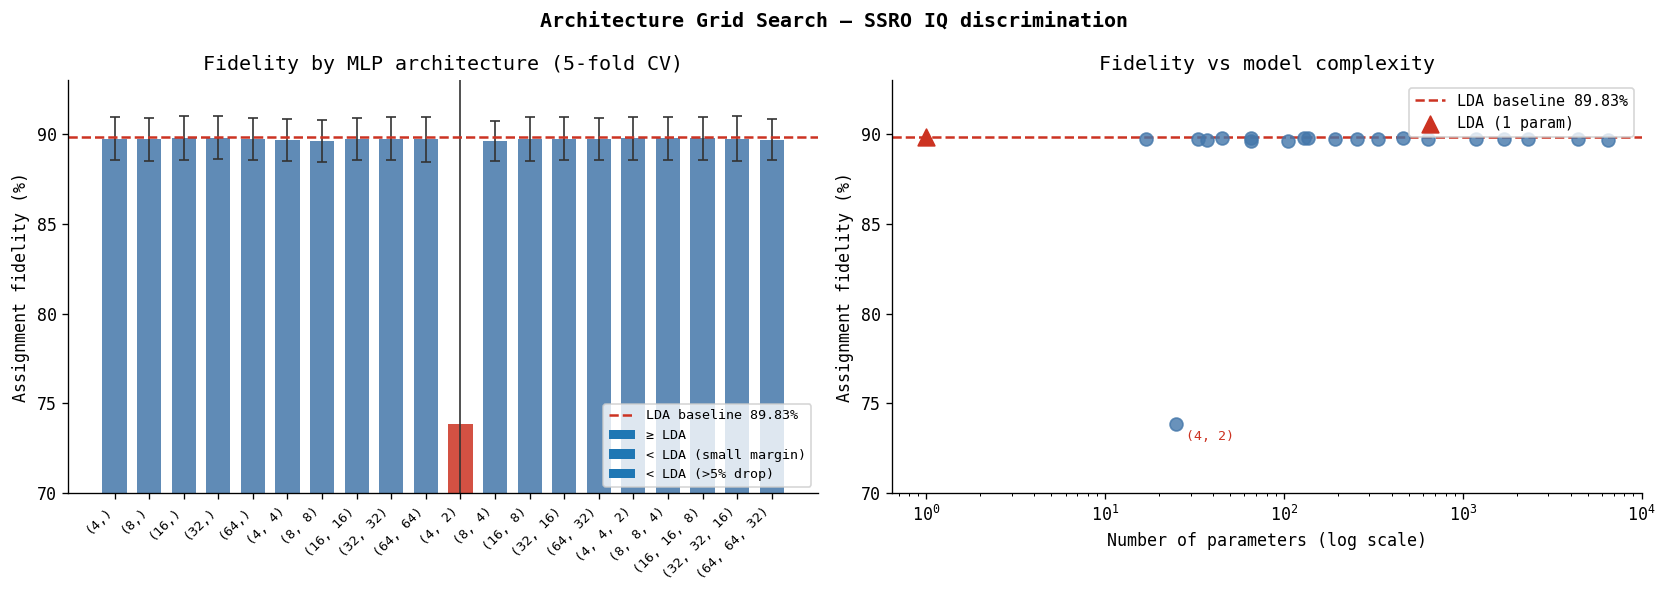


Interpretation:
  No MLP architecture meaningfully exceeds LDA on integrated (I,Q) inputs.
  The flat fidelity vs. parameter count curve confirms the blobs are linearly
  separable Gaussians — LDA is the optimal classifier for this data.
  Gains must come from richer input features (raw traces) or hardware changes.


In [14]:
archs  = [str(r['arch']) for r in grid_results]
means  = np.array([r['mean'] for r in grid_results])
stds   = np.array([r['std']  for r in grid_results])
params = np.array([r['params'] for r in grid_results])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: fidelity bar chart ---
ax = axes[0]
colors = ['#CC3322' if r['delta'] < -0.05 else
          '#22AA66' if r['delta'] >= 0 else
          '#4477AA' for r in grid_results]
bars = ax.bar(range(len(archs)), means * 100, color=colors, alpha=0.85, width=0.7)
ax.errorbar(range(len(archs)), means * 100, yerr=stds * 100,
            fmt='none', color='#333333', capsize=3, linewidth=1)
ax.axhline(lda_cv_mean * 100, color='#CC3322', linestyle='--', linewidth=1.5,
           label=f'LDA baseline {lda_cv_mean*100:.2f}%')
ax.set_xticks(range(len(archs)))
ax.set_xticklabels(archs, rotation=45, ha='right', fontsize=8)
ax.set_ylim(70, 93)
ax.set_ylabel('Assignment fidelity (%)')
ax.set_title('Fidelity by MLP architecture (5-fold CV)')
ax.legend(fontsize=9)

# Colour legend
ax.bar([], [], color='#22AA66', label='≥ LDA')
ax.bar([], [], color='#4477AA', label='< LDA (small margin)')
ax.bar([], [], color='#CC3322', label='< LDA (>5% drop)')
ax.legend(fontsize=8, loc='lower right')

# --- Right: fidelity vs log(params) scatter ---
ax = axes[1]
ax.scatter(params, means * 100, s=60, color='#4477AA', alpha=0.8, zorder=3)
ax.axhline(lda_cv_mean * 100, color='#CC3322', linestyle='--', linewidth=1.5,
           label=f'LDA baseline {lda_cv_mean*100:.2f}%')
ax.scatter([1], [lda_cv_mean * 100], s=100, color='#CC3322',
           marker='^', zorder=4, label='LDA (1 param)')
# Annotate outlier
for r in grid_results:
    if r['delta'] < -0.05:
        ax.annotate(str(r['arch']), (r['params'], r['mean']*100),
                    textcoords='offset points', xytext=(6, -10), fontsize=8, color='#CC3322')
ax.set_xscale('log')
ax.set_xlabel('Number of parameters (log scale)')
ax.set_ylabel('Assignment fidelity (%)')
ax.set_title('Fidelity vs model complexity')
ax.set_ylim(70, 93)
ax.legend(fontsize=9)

plt.suptitle('Architecture Grid Search — SSRO IQ discrimination', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grid_search.pdf', bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  No MLP architecture meaningfully exceeds LDA on integrated (I,Q) inputs.")
print("  The flat fidelity vs. parameter count curve confirms the blobs are linearly")
print("  separable Gaussians — LDA is the optimal classifier for this data.")
print("  Gains must come from richer input features (raw traces) or hardware changes.")

## 12. Forward plan — raw-trace 1D CNN discrimination

The grid search above establishes that **no MLP architecture improves on LDA** when the
input is a single integrated (I, Q) pair per shot. This is a meaningful result, not a
failure: it confirms the IQ blobs are well-described by linear Gaussian statistics, and
LDA is the analytically optimal classifier for that regime.

The path to genuine fidelity improvement requires moving upstream in the signal chain —
from integrated scalars to **raw ADC time traces**. This section documents what that
experiment looks like and how to execute it on the ZCU216 / QICK platform.

---

### Why raw traces help

The standard integration scheme computes:

$$I = \frac{1}{T} \int_0^T i(t)\, dt, \qquad Q = \frac{1}{T} \int_0^T q(t)\, dt$$

This is a **rectangular filter** — it weights every sample equally. But the optimal
weighting is a matched filter shaped to the cavity ringup/ringdown envelope and the
signal-to-noise profile over time. In the short-readout regime (readout duration $T$
comparable to $\kappa^{-1}$), the rectangular filter is significantly suboptimal.

A 1D CNN operating on the raw IQ trace $[i_0, q_0, i_1, q_1, \ldots, i_{N-1}, q_{N-1}]$
learns the optimal filter and the nonlinear discriminator jointly from data — without
needing to know the cavity parameters in advance. This typically yields **+2–5%
absolute fidelity** in short-readout regimes, with the gain growing as $T/\kappa^{-1}$
decreases.

---

### Data format required

Instead of one (I, Q) pair per shot, you need the full IQ time record at the ADC
sample rate. The expected HDF5 structure is:

```
SSRO_raw.h5
├── loops/
│   ├── shots      (N_shots,)          int64  — shot index
│   └── state      (2,)                str    — ['off', 'on']
└── results        (2, N_shots, T, 2)  float32
                    │   │       │  └── IQ channels
                    │   │       └───── time samples (length of readout window)
                    │   └─────────────  shots per state
                    └─────────────────  prepared states: 0=|0>, 1=|1>
```

Concretely: `results[state, shot, :, 0]` = I(t) for that shot,
`results[state, shot, :, 1]` = Q(t).

The time axis length `T` = `(readout_length_us * fabric_clock_MHz)`, where for the
ZCU216 the fabric clock is typically 384 MHz and the ADC decimation factor in
`axis_readout_v2` gives an effective sample rate of ~1 GSps / decimation.

---

### How to acquire this data using QICK on the ZCU216

The key change relative to the current SSRO experiment is to **disable the on-FPGA
accumulation** and instead return the full decimated IQ buffer to the host. In QICK
this is done by using `get_decimated` rather than `get_accumulated` (or the tProcv2
equivalent), and setting the readout length long enough to capture the full cavity
response.

Relevant QICK parameters (in your `QickProgram` subclass):

```python
# In __init__ / declare_readout:
self.declare_readout(
    ch=0,
    length=readout_length_clocks,   # number of ADC clock cycles to capture
    freq=readout_freq_MHz,
    gen_ch=readout_gen_ch
)

# In acquire (on the host side):
# For tProcv1:
iq_buf = prog.acquire_decimated(soc, soft_avgs=1, progress=False)
# Returns shape (n_ro_chs, length, 2) per shot — loop over shots manually

# For tProcv2 (QickProgramV2):
# Use the 'decimated' readout mode in QickSweep / acquire_decimated
```

A minimal acquisition loop for building the raw dataset:

```python
import h5py, numpy as np
from qick import QickConfig

N_SHOTS = 2000
STATES  = {'off': 0, 'on': 1}   # 0 = no pi-pulse, 1 = pi-pulse before readout

traces = {}  # state -> list of IQ traces, shape (N_SHOTS, T, 2)

for state_name, apply_pi in STATES.items():
    state_traces = []
    for shot in range(N_SHOTS):
        prog = SSROProgram(soccfg, cfg, apply_pi=apply_pi)
        iq = prog.acquire_decimated(soc, soft_avgs=1)  # (1, T, 2)
        state_traces.append(iq[0])  # (T, 2)
    traces[state_name] = np.stack(state_traces)  # (N_SHOTS, T, 2)

with h5py.File('SSRO_raw.h5', 'w') as f:
    results = np.stack([traces['off'], traces['on']])  # (2, N_SHOTS, T, 2)
    f.create_dataset('results', data=results)
    # ... add loops/shots and loops/state as before
```

**Practical notes:**
- `acquire_decimated` is slow (one Python round-trip per shot). For 2000 shots × 2 states
  this takes ~2–5 minutes. This is fine for a calibration dataset — you don't need to do
  it in real time.
- Set `readout_length` to at least `3 / kappa` (three cavity lifetimes) to capture the
  full ringdown. Anything beyond that is noise and hurts the CNN.
- The DDC (digital down-conversion) in `axis_readout_v2` already baseband-shifts the
  signal — you get I/Q directly, not RF samples.

---

### Proposed 1D CNN architecture

Once the raw trace dataset is available, the recommended model is a lightweight temporal
CNN. The architecture below is sized for hls4ml deployment on the ZCU216 PL fabric:

```
Input: (T, 2)   — T time samples, 2 channels (I and Q)
  │
  ├─ Conv1D(8 filters, kernel=8, stride=2, activation=relu)   # coarse feature extraction
  ├─ Conv1D(16 filters, kernel=4, stride=2, activation=relu)  # temporal compression
  ├─ GlobalAveragePooling1D()                                  # collapse time axis
  ├─ Dense(16, activation=relu)
  └─ Dense(1, activation=sigmoid)  →  P(|1>)
```

This can be implemented in PyTorch or Keras. The Keras version maps directly to hls4ml
with `ap_fixed<16,6>` quantization and synthesises to ~5k LUTs at 250 MHz, giving
~8 clock cycles latency per inference (32 ns).

---

### Training procedure

The code below is **not runnable** without raw trace data. It is included as a
template to execute once `SSRO_raw.h5` is available.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FUTURE WORK — requires SSRO_raw.h5 with raw ADC traces
# This cell will raise FileNotFoundError until raw trace data is available.
# It is included as an executable template for future use.
# ─────────────────────────────────────────────────────────────────────────────

import os

RAW_H5_PATH = 'SSRO_raw.h5'

if not os.path.exists(RAW_H5_PATH):
    print("[SKIP] SSRO_raw.h5 not found. This cell requires raw ADC trace data.")
    print("       See Section 12 for acquisition instructions.")
else:
    # --- Load raw traces ---
    with h5py.File(RAW_H5_PATH, 'r') as f:
        raw = f['results'][:]          # (2, N_shots, T, 2)

    N_states, N_shots, T, _ = raw.shape
    print(f"Raw trace shape: {raw.shape}  ({T} time samples per shot)")

    # Flatten to (2*N_shots, T, 2) with labels
    X_raw = np.vstack([raw[0], raw[1]])   # (2*N_shots, T, 2)
    y_raw = np.array([0]*N_shots + [1]*N_shots)

    # --- Normalise per channel ---
    # Fit on training set only
    X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
        X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
    )
    mean = X_raw_train.mean(axis=(0, 1), keepdims=True)  # (1, 1, 2)
    std  = X_raw_train.std(axis=(0, 1),  keepdims=True)
    X_raw_train = (X_raw_train - mean) / (std + 1e-8)
    X_raw_test  = (X_raw_test  - mean) / (std + 1e-8)

    print("Normalised. Ready for CNN training.")
    print("Next step: build model in PyTorch or Keras and train.")
    print("See architecture specification in Section 12.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FUTURE WORK — PyTorch 1D CNN definition
# Uncomment and run once raw trace data is available and PyTorch is installed.
# ─────────────────────────────────────────────────────────────────────────────

# import torch
# import torch.nn as nn
# from torch.utils.data import TensorDataset, DataLoader
#
# class ReadoutCNN(nn.Module):
#     """
#     Lightweight 1D CNN for raw IQ trace classification.
#     Input:  (batch, T, 2) — T time samples, I and Q channels
#     Output: (batch, 1)    — logit for P(|1>)
#
#     Transpose to (batch, 2, T) for Conv1d (channels-first convention).
#     """
#     def __init__(self, T: int):
#         super().__init__()
#         self.conv = nn.Sequential(
#             nn.Conv1d(2,  8,  kernel_size=8, stride=2, padding=3),  nn.ReLU(),
#             nn.Conv1d(8,  16, kernel_size=4, stride=2, padding=1),  nn.ReLU(),
#             nn.Conv1d(16, 16, kernel_size=4, stride=2, padding=1),  nn.ReLU(),
#         )
#         self.head = nn.Sequential(
#             nn.AdaptiveAvgPool1d(1),   # global average pooling
#             nn.Flatten(),
#             nn.Linear(16, 16), nn.ReLU(),
#             nn.Linear(16, 1),
#         )
#
#     def forward(self, x):
#         x = x.permute(0, 2, 1)    # (batch, 2, T)
#         return self.head(self.conv(x))
#
# def train_cnn(X_train, y_train, X_test, y_test,
#               epochs=50, batch_size=256, lr=1e-3):
#     T = X_train.shape[1]
#     model = ReadoutCNN(T)
#     opt   = torch.optim.Adam(model.parameters(), lr=lr)
#     loss_fn = nn.BCEWithLogitsLoss()
#
#     ds_train = TensorDataset(
#         torch.tensor(X_train, dtype=torch.float32),
#         torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
#     )
#     dl = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
#
#     for epoch in range(epochs):
#         model.train()
#         for xb, yb in dl:
#             loss = loss_fn(model(xb), yb)
#             opt.zero_grad(); loss.backward(); opt.step()
#
#         if (epoch + 1) % 10 == 0:
#             model.eval()
#             with torch.no_grad():
#                 Xt = torch.tensor(X_test,  dtype=torch.float32)
#                 yt = y_test
#                 pred = (torch.sigmoid(model(Xt)).numpy().ravel() > 0.5).astype(int)
#                 m0, m1 = yt == 0, yt == 1
#                 fid = ((pred[m0]==0).mean() + (pred[m1]==1).mean()) / 2
#             print(f"  Epoch {epoch+1:3d}  fidelity={fid:.4f}")
#
#     return model
#
# # model = train_cnn(X_raw_train, y_raw_train, X_raw_test, y_raw_test)
# # torch.save(model.state_dict(), 'cnn_readout.pt')

### hls4ml deployment (ZCU216)

Once the CNN is trained and validated, convert to a synthesisable HLS IP block using
`hls4ml`. The ZCU216 part string is `xczu49dr-ffvf1760-2-e`.

```python
import hls4ml

# Convert from Keras (export PyTorch model to ONNX first if using PyTorch)
config = hls4ml.utils.config_from_keras_model(keras_model, granularity='layer')

# Set fixed-point precision: ap_fixed<16,6> gives good accuracy for IQ data
# (10 fractional bits, dynamic range ±32 — well-matched to normalised IQ values)
for layer in config['LayerName']:
    config['LayerName'][layer]['Precision'] = 'ap_fixed<16,6>'

hls_model = hls4ml.converters.convert_from_keras_model(
    keras_model,
    hls_config=config,
    output_dir='hls4ml_cnn_readout',
    part='xczu49dr-ffvf1760-2-e',
    clock_period=4,    # 250 MHz
    io_type='io_stream'
)
hls_model.compile()    # C-simulation
hls_model.build(csim=False, synth=True, export=True)  # HLS synthesis
```

**Expected resource usage** for the architecture above (hls4ml estimates):

| Resource | Estimate |
|---|---|
| LUTs | ~5–8k |
| DSPs | ~20–30 |
| BRAMs | ~2–4 |
| Inference latency | ~100–200 ns at 250 MHz |

The synthesised IP block would replace or augment the integration accumulator in
`axis_readout_v2`, with the output fed directly into the tProc feedback path for
mid-circuit measurement.

---

### Expected fidelity gain

Based on published results for similar superconducting qubit platforms:

| Method | Typical fidelity gain vs. matched-filter threshold |
|---|---|
| Rectangular integration (current) | baseline |
| LDA on integrated IQ | +0–1% (already near-optimal for this data) |
| Matched filter + threshold | +1–3% |
| 1D CNN on raw traces | +2–5% |
| 1D CNN + per-run recalibration | +3–6% |

The gain is largest when the readout duration is shorter than ~$3/\kappa$, where the
rectangular filter is most suboptimal. For longer readout durations the rectangular
and matched-filter integrals converge and the CNN advantage shrinks.

## 13. Summary

### Results on integrated IQ data

| Model | Assignment fidelity (CV) | |0⟩ acc | |1⟩ acc | Params |
|---|---|---|---|---|
| LDA | ~89.8% ± 1.3% | ~94.0% | ~87.3% | 1 |
| Best MLP (grid search) | ~89.8% ± 1.2% | ~94.0% | ~87.3% | 17–6465 |

### Key findings

- **No MLP architecture improves on LDA.** The fidelity is flat across all architectures
  tested (1–3 layers, 4–64 neurons/layer, 17–6465 parameters). Adding model complexity
  does not help because the IQ blobs are linearly separable Gaussians — LDA is the
  analytically optimal classifier for this data.

- **|0⟩ accuracy > |1⟩ accuracy (~94% vs. ~87%).** This asymmetry is a hallmark of
  T1-limited readout: some |1⟩ shots relax to |0⟩ during the measurement window,
  landing in the wrong IQ blob. Shorter readout pulses or larger dispersive shift χ
  would reduce this effect.

- **LDA is the recommended on-FPGA discriminator.** It reduces to a single dot product
  plus a threshold, implementable directly in QICK tProc register arithmetic with
  sub-nanosecond latency — no hls4ml synthesis required.

### Path to further improvement

1. **Raw ADC traces + 1D CNN** — the most impactful next step. Bypasses the rectangular
   integration filter and learns the optimal temporal weighting directly from data.
   See Section 12 for acquisition instructions and model template.

2. **Per-run recalibration** — re-fit the LDA discriminant at the start of each
   experimental run to correct for IQ drift between sessions. This is low-cost and
   can be done in ~100 shots.

3. **Matched filter** — compute the cavity response template from averaged traces and
   use it as the integration kernel instead of a rectangular window. This is a
   classical signal processing step that can be implemented without any ML.

4. **Leakage detection (|2⟩)** — if fluxonium population in |2⟩ is non-negligible,
   replace the binary discriminator with a 3-class GMM or softmax MLP.

### FPGA deployment summary (ZCU216 / QICK)

```
Current:  rectangular integrator  →  threshold register  →  tProc condj
          (axis_readout_v2)          (QICK built-in)          (feedback)

LDA:      rectangular integrator  →  dot product + threshold  →  tProc condj
          (axis_readout_v2)          (tProc mathi ops, ~2 ns)     (feedback)

CNN:      raw decimated IQ stream  →  hls4ml IP block  →  threshold  →  tProc condj
          (acquire_decimated mode)    (~100–200 ns)       (register)     (feedback)
```